# Find which community influences our cluster subtypes more

In [1]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap  
import shap  

In [2]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


# Doing random forest on combined full and partial transition

Use noteboook: 'Analyse Cluster Backtrack.ipynb' for data

In [3]:
data=reader.data_read_pkl('raw/cluster_label.pkl')

These are whole embeddings (full and partial combined) with corresponding labels  
Though we need to use labels only

In [ ]:
data['label'][2].shape

(289,)

GEt combined original data

In [4]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))

original_data=[]

for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    
    df_combined= pd.concat([df_full,df_part],axis = 0)

    original_data.append(df_combined.values)


In [5]:
comm=list(reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn').columns)


In [6]:
original_data[2].shape

(289, 8)

Let's concatenate all data and see

In [7]:
X_list=original_data.copy()
y_list=data['label']



X_all = np.vstack(X_list)   # shape (3757, 8)
y_all = np.hstack(y_list)   # shape (3757,)

rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf.fit(X_all, y_all)

print("Global feature importances:", rf.feature_importances_)



Global feature importances: [0.08809026 0.10420514 0.19191265 0.19229363 0.16170467 0.14611826
 0.087032   0.02864339]


Global feature importances: [0.08809026 0.10420514 0.19191265 0.19229363 0.16170467 0.14611826
 0.087032   0.02864339]
SHAP values shape: (2875, 8, 5)

Cluster-specific feature importance:
       Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4
mo     0.028235   0.032547   0.028014   0.028326   0.050385
vis    0.041370   0.061257   0.044685   0.013587   0.068819
orb    0.081884   0.047442   0.093409   0.073753   0.052928
hth    0.085803   0.069217   0.100571   0.032166   0.076875
olf    0.064475   0.062637   0.032904   0.077528   0.035930
hipp   0.044212   0.033814   0.095606   0.035465   0.071349
mid    0.031212   0.033894   0.047098   0.013791   0.032842
hind   0.005900   0.014268   0.007018   0.000840   0.014655


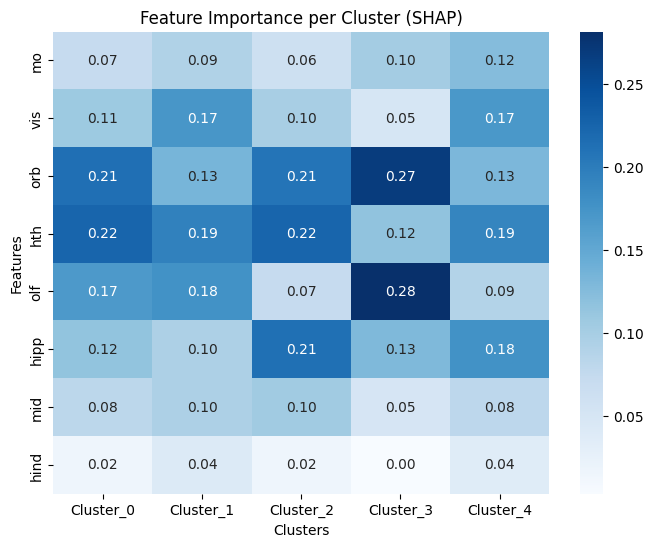


Top 2 features per cluster:
 {'Cluster_0': ['hth', 'orb'], 'Cluster_1': ['hth', 'olf'], 'Cluster_2': ['hth', 'hipp'], 'Cluster_3': ['olf', 'orb'], 'Cluster_4': ['hth', 'hipp']}


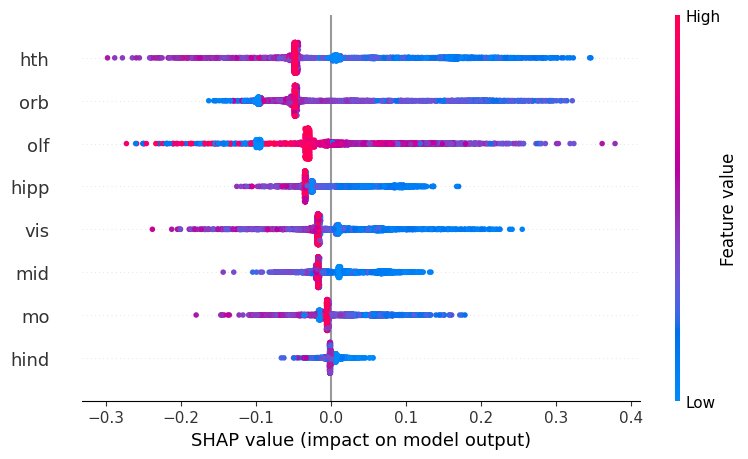

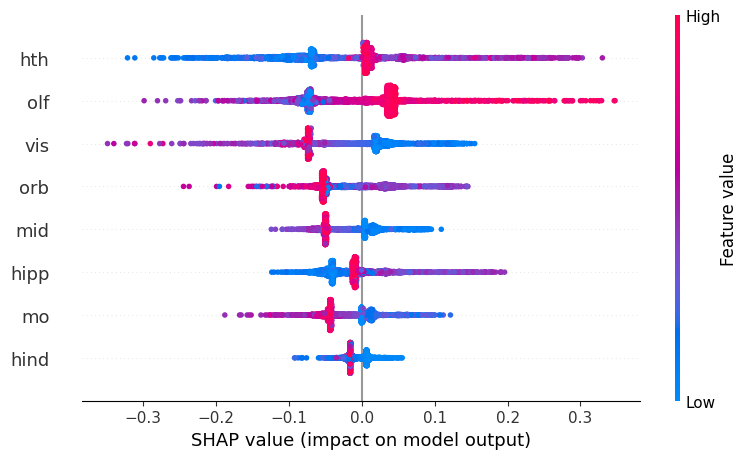

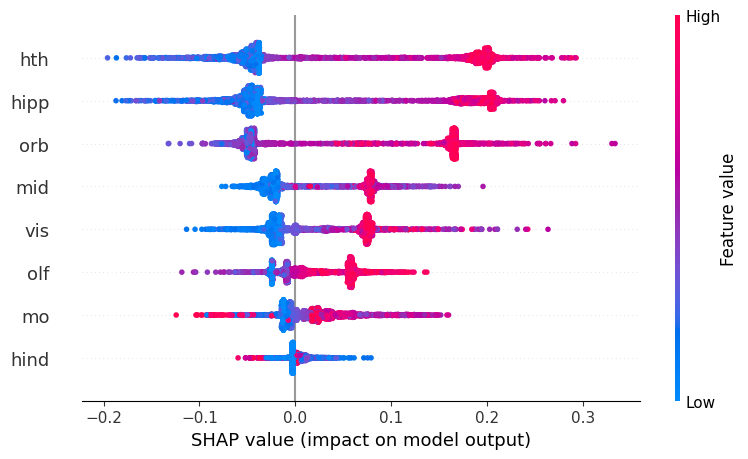

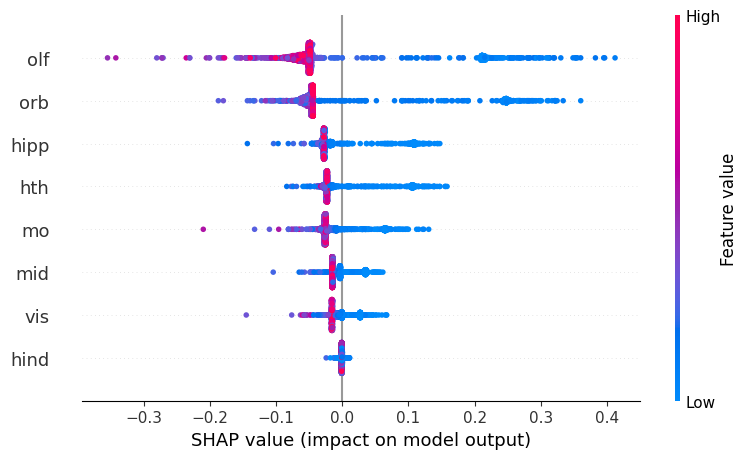

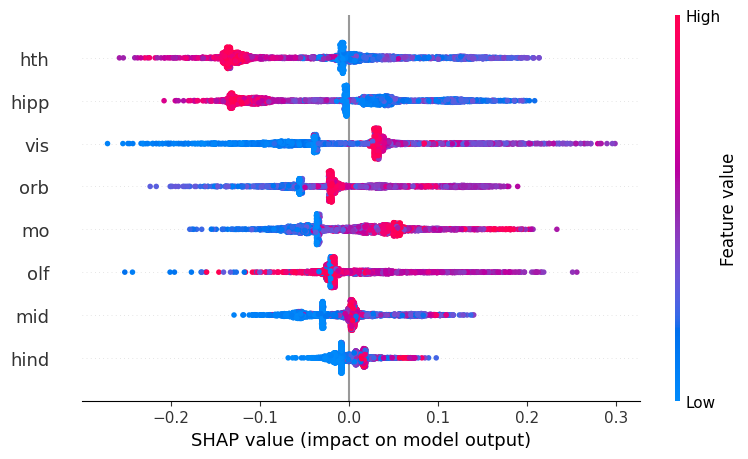

In [8]:


# --- Your combined dataset ---
X_all = np.vstack(X_list)   # shape (2875, 8)
y_all = np.hstack(y_list)   # shape (2875,)
feature_names = comm

# --- 1. Train Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf.fit(X_all, y_all)

print("Global feature importances:", rf.feature_importances_)

# --- 2. SHAP explainer ---
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_all)  
# New behavior: shap_values is shape (n_samples, n_features, n_classes)

print("SHAP values shape:", shap_values.shape)

# --- 3. Convert to per-cluster arrays ---
# Slice along the last axis to get one array per cluster
shap_values_list = [shap_values[:,:,i] for i in range(shap_values.shape[2])]

# --- 4. Aggregate SHAP values per cluster ---
cluster_feature_importance = {}
for cluster_id, class_shap in enumerate(shap_values_list):
    mean_abs_shap = np.abs(class_shap).mean(axis=0)  # length = 8 features
    cluster_feature_importance[f"Cluster_{cluster_id}"] = mean_abs_shap

importance_df = pd.DataFrame(cluster_feature_importance, index=feature_names)
print("\nCluster-specific feature importance:\n", importance_df)

# --- 5. Normalize per cluster for easier comparison ---
importance_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# --- 6. Heatmap visualization ---
plt.figure(figsize=(8,6))
sns.heatmap(importance_norm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Importance per Cluster (SHAP)")
plt.ylabel("Features")
plt.xlabel("Clusters")
plt.show()

# --- 7. Top 2 features per cluster ---
top_features = {}
for cluster in importance_df.columns:
    top_features[cluster] = importance_df[cluster].nlargest(2).index.tolist()

print("\nTop 2 features per cluster:\n", top_features)

# --- 8. Optional: SHAP summary plots for each cluster ---
for i, class_shap in enumerate(shap_values_list):
    shap.summary_plot(class_shap, X_all, feature_names=feature_names)


In [9]:


# shap_values shape: (n_samples, n_features, n_classes)
# Aggregate across classes if you want overall importance
mean_abs_shap = np.abs(shap_values).mean(axis=(0,2))  # length = n_features

importance_table = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False)

print(importance_table)


  Feature  Mean |SHAP|
3     hth     0.072927
2     orb     0.069883
5    hipp     0.056089
4     olf     0.054695
1     vis     0.045944
0      mo     0.033501
6     mid     0.031767
7    hind     0.008536


dict_keys(['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3', 'Cluster_4', 'Cluster_5', 'Cluster_6', 'Cluster_7', 'Cluster_8', 'Cluster_9', 'Cluster_10', 'Cluster_11', 'Cluster_12', 'Cluster_13', 'Cluster_14', 'Cluster_15', 'Cluster_16', 'Cluster_17', 'Cluster_18', 'Cluster_19', 'Cluster_20', 'Cluster_21', 'Cluster_22', 'Cluster_23', 'Cluster_24', 'Cluster_25', 'Cluster_26', 'Cluster_27', 'Cluster_28', 'Cluster_29', 'Cluster_30', 'Cluster_31', 'Cluster_32', 'Cluster_33', 'Cluster_34', 'Cluster_35', 'Cluster_36', 'Cluster_37', 'Cluster_38', 'Cluster_39', 'Cluster_40', 'Cluster_41', 'Cluster_42', 'Cluster_43', 'Cluster_44', 'Cluster_45', 'Cluster_46', 'Cluster_47', 'Cluster_48', 'Cluster_49', 'Cluster_50', 'Cluster_51', 'Cluster_52', 'Cluster_53', 'Cluster_54', 'Cluster_55', 'Cluster_56', 'Cluster_57', 'Cluster_58', 'Cluster_59', 'Cluster_60', 'Cluster_61', 'Cluster_62', 'Cluster_63', 'Cluster_64', 'Cluster_65', 'Cluster_66', 'Cluster_67', 'Cluster_68', 'Cluster_69', 'Cluster_70', 'Clus

Text(0, 0.5, 'importance for clustering subtype')

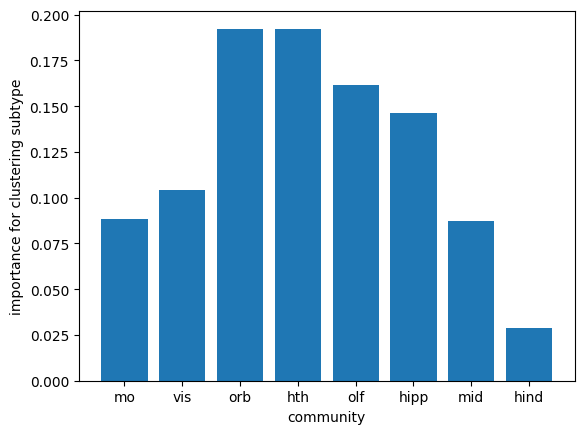

In [10]:
plt.bar(comm,rf.feature_importances_)
plt.xlabel('community')
plt.ylabel('importance for clustering subtype')

## Only making SHAP considering partial transitions [This is used in supplementary]

Getting only partial newtorks data

In [11]:
data_folder=Path('../../data/results/comm_umap_results/')
file_part=glob.glob(str(data_folder/'pca_part_df_*'))

original_data=[]

for f_part in file_part:
    
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    original_data.append(df_part.values)


Loading partial network labels

In [12]:
data=reader.data_read_pkl('raw/part_cluster_label.pkl')

In [8]:
data['label'][2].shape

(186,)

In [9]:
original_data[2].shape

(186, 8)

Do random forest

In [13]:
X_list=original_data.copy()
y_list=data['label']



X_all = np.vstack(X_list)   
y_all = np.hstack(y_list)   

rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf.fit(X_all, y_all)

print("Global feature importances for partial transitions only:", rf.feature_importances_)



Global feature importances for partial transitions only: [0.09001596 0.1034002  0.19940535 0.18024685 0.17219799 0.13309168
 0.09217676 0.02946522]


In [14]:
comm=list(reader.data_read_bz2('results/comm_umap_results/pca_part_df_fn').columns)


Text(0.5, 1.0, 'Considering only Partial Transitions')

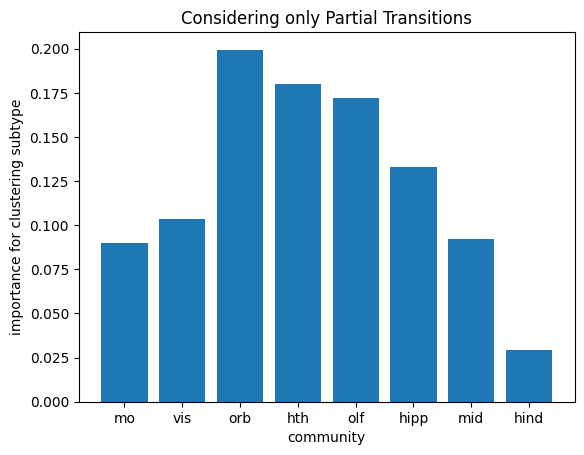

In [15]:
plt.bar(comm,rf.feature_importances_)
plt.xlabel('community')
plt.ylabel('importance for clustering subtype')
plt.title('Considering only Partial Transitions')

Global feature importances: [0.09001596 0.1034002  0.19940535 0.18024685 0.17219799 0.13309168
 0.09217676 0.02946522]
SHAP values shape: (1925, 8, 5)

Cluster-specific feature importance:
       Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5
mo     0.040681   0.025374   0.021146   0.029153   0.054650
vis    0.052385   0.051578   0.029320   0.014214   0.083824
orb    0.099210   0.047131   0.071513   0.089188   0.067147
hth    0.104629   0.096325   0.061922   0.036614   0.057219
olf    0.082371   0.073617   0.029346   0.090610   0.047031
hipp   0.048414   0.044042   0.055176   0.036627   0.052833
mid    0.040851   0.032056   0.036079   0.015151   0.048570
hind   0.007264   0.013604   0.006249   0.000778   0.013226


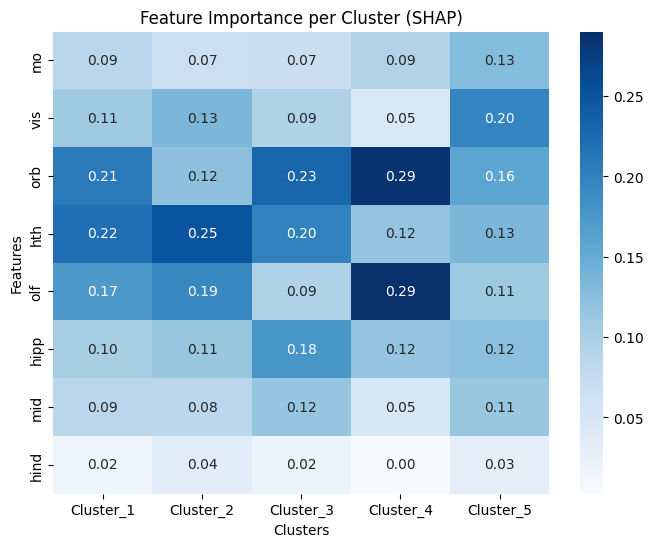


Top 2 features per cluster:
 {'Cluster_1': ['hth', 'orb'], 'Cluster_2': ['hth', 'olf'], 'Cluster_3': ['orb', 'hth'], 'Cluster_4': ['olf', 'orb'], 'Cluster_5': ['vis', 'orb']}


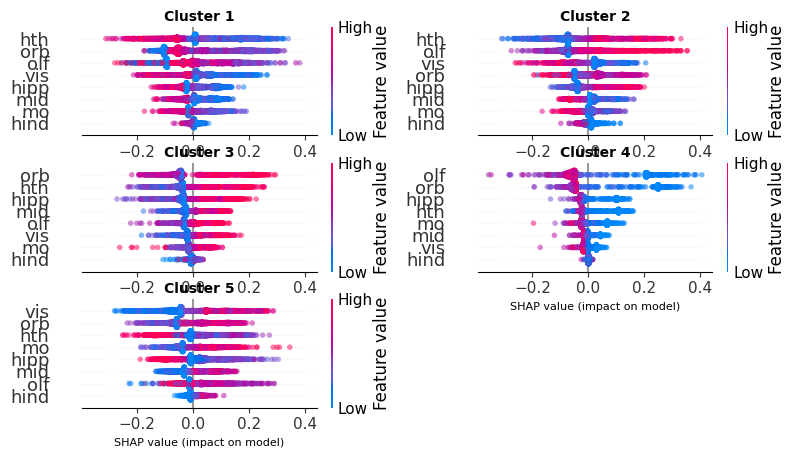

In [20]:


# Assuming feature_names, X_all, and y_all are already defined
feature_names = comm

# --- 1. Train Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf.fit(X_all, y_all)

print("Global feature importances:", rf.feature_importances_)

# --- 2. SHAP explainer ---
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_all)  
# Shape: (n_samples, n_features, n_classes)

print("SHAP values shape:", shap_values.shape)

# --- 3. Convert to per-cluster arrays ---
shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# --- 4. Aggregate SHAP values per cluster (Mapped 1-5) ---
cluster_feature_importance = {}
for cluster_id, class_shap in enumerate(shap_values_list):
    mean_abs_shap = np.abs(class_shap).mean(axis=0)  # length = 8 features
    # Mapping cluster 0-4 to 1-5 here
    cluster_feature_importance[f"Cluster_{cluster_id + 1}"] = mean_abs_shap

importance_df = pd.DataFrame(cluster_feature_importance, index=feature_names)
print("\nCluster-specific feature importance:\n", importance_df)

# --- 5. Normalize per cluster for easier comparison ---
importance_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# --- 6. Heatmap visualization ---
plt.figure(figsize=(8, 6))
sns.heatmap(importance_norm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Importance per Cluster (SHAP)")
plt.ylabel("Features")
plt.xlabel("Clusters")
plt.show()

# --- 7. Top 2 features per cluster ---
top_features = {}
for cluster in importance_df.columns:
    top_features[cluster] = importance_df[cluster].nlargest(2).index.tolist()

print("\nTop 2 features per cluster:\n", top_features)

# --- 8. Combined SHAP summary plots for each cluster (Shared X-axis & Compact Sizing) ---

# 1. Scale down global font settings for a tighter, cleaner profile
plt.rcParams.update({
    'font.size': 8,           # General text size
    'axes.labelsize': 8,       # Axis labels 
    'xtick.labelsize': 7,      # X-axis tick numbers
    'ytick.labelsize': 8       # Y-axis feature labels
})

# 2. Initialize the grid with shared X-axes and a smaller overall figure size (10x10)
fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex=True) 
axes_flat = axes.flatten()

for i, class_shap in enumerate(shap_values_list):
    plt.sca(axes_flat[i]) 
    
    # 3. Drop alpha slightly to 0.5 to keep overlapping dense dots manageable at a smaller scale
    shap.summary_plot(
        class_shap, 
        X_all, 
        feature_names=feature_names, 
        alpha=0.5,   
        show=False
    )
    
    # 4. Clean up titles and individual x-axis labels
    plt.title(f'Cluster {i + 1}', fontsize=10, fontweight='bold', pad=4)
    
    # Only show the X label on the bottom plots to keep the middle layout clean
    if i < 3:
        plt.xlabel("")
    else:
        plt.xlabel("SHAP value (impact on model)", fontsize=8)

# Remove the unused 6th panel
if len(axes_flat) > len(shap_values_list):
    for j in range(len(shap_values_list), len(axes_flat)):
        fig.delaxes(axes_flat[j])

# 5. Compact padding rules
plt.subplots_adjust(wspace=0.35, hspace=0.25)

plt.show()

# Reset font properties back to default
plt.rcParams.update(plt.rcParamsDefault)

Global feature importances: [0.09001596 0.1034002  0.19940535 0.18024685 0.17219799 0.13309168
 0.09217676 0.02946522]
SHAP values shape: (1925, 8, 5)

Cluster-specific feature importance:
       Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4
mo     0.040681   0.025374   0.021146   0.029153   0.054650
vis    0.052385   0.051578   0.029320   0.014214   0.083824
orb    0.099210   0.047131   0.071513   0.089188   0.067147
hth    0.104629   0.096325   0.061922   0.036614   0.057219
olf    0.082371   0.073617   0.029346   0.090610   0.047031
hipp   0.048414   0.044042   0.055176   0.036627   0.052833
mid    0.040851   0.032056   0.036079   0.015151   0.048570
hind   0.007264   0.013604   0.006249   0.000778   0.013226


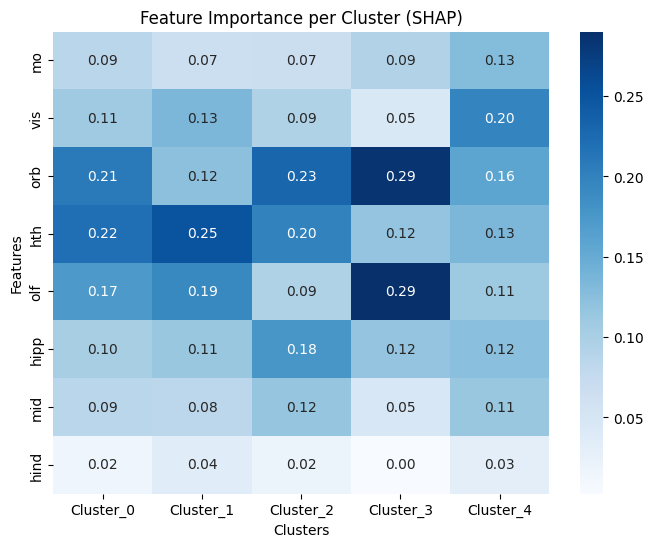


Top 2 features per cluster:
 {'Cluster_0': ['hth', 'orb'], 'Cluster_1': ['hth', 'olf'], 'Cluster_2': ['orb', 'hth'], 'Cluster_3': ['olf', 'orb'], 'Cluster_4': ['vis', 'orb']}
cluster0


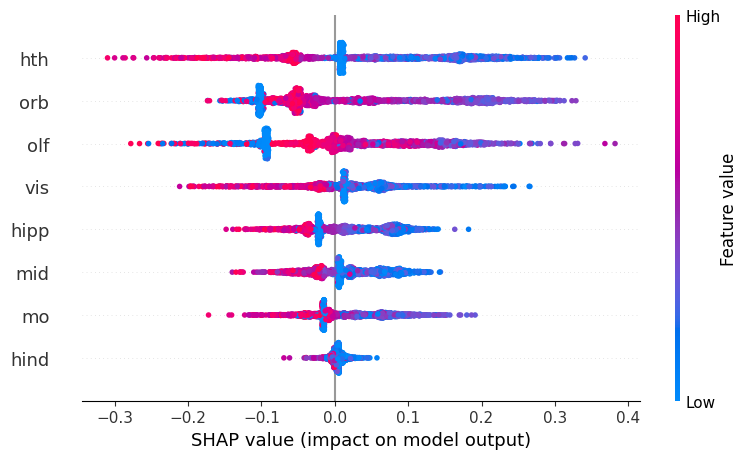

cluster1


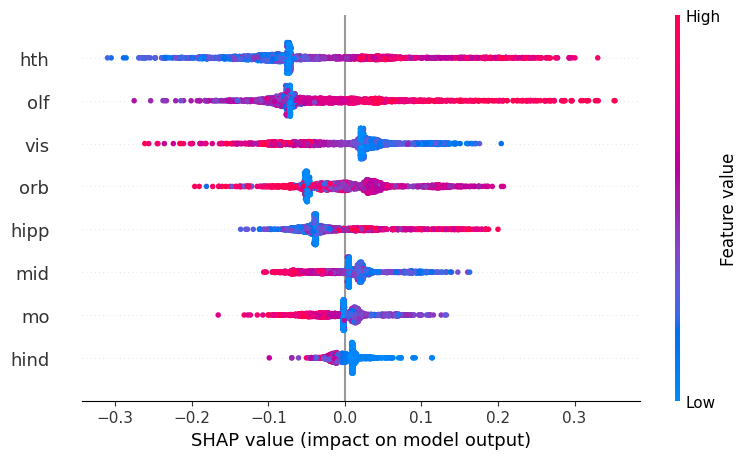

cluster2


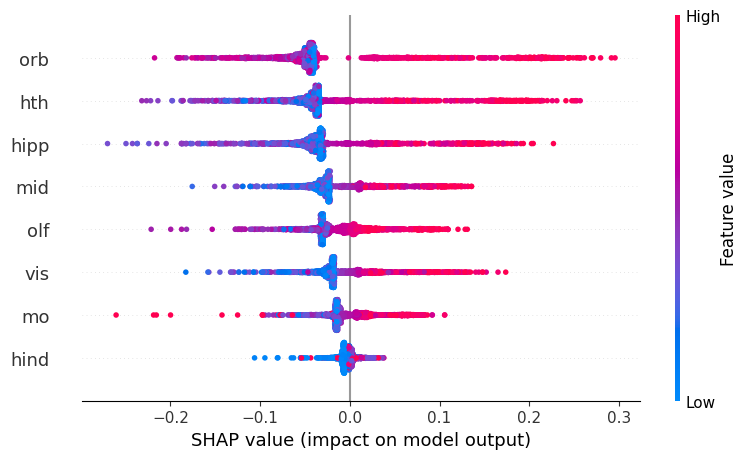

cluster3


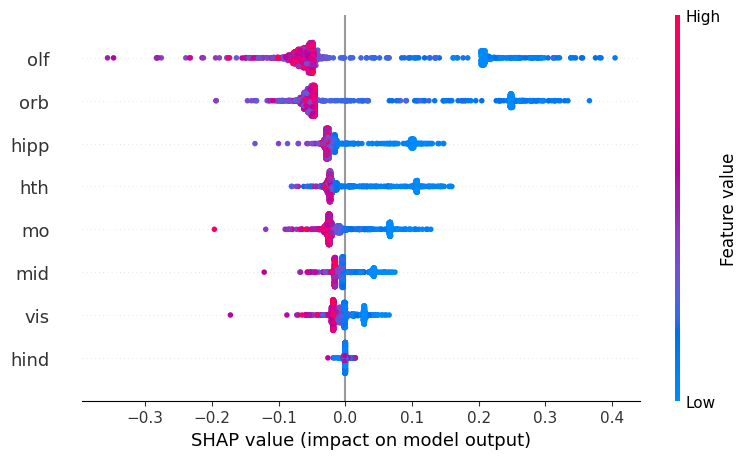

cluster4


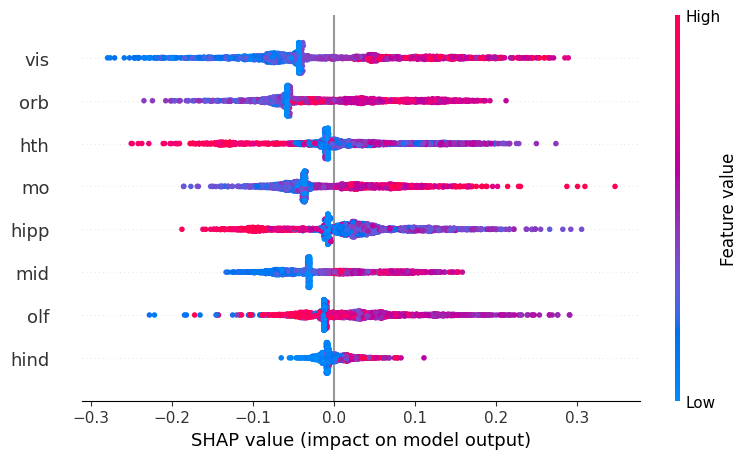

In [16]:

feature_names = comm

# --- 1. Train Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf.fit(X_all, y_all)

print("Global feature importances:", rf.feature_importances_)

# --- 2. SHAP explainer ---
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_all)  
# New behavior: shap_values is shape (n_samples, n_features, n_classes)

print("SHAP values shape:", shap_values.shape)

# --- 3. Convert to per-cluster arrays ---
# Slice along the last axis to get one array per cluster
shap_values_list = [shap_values[:,:,i] for i in range(shap_values.shape[2])]

# --- 4. Aggregate SHAP values per cluster ---
cluster_feature_importance = {}
for cluster_id, class_shap in enumerate(shap_values_list):
    mean_abs_shap = np.abs(class_shap).mean(axis=0)  # length = 8 features
    cluster_feature_importance[f"Cluster_{cluster_id}"] = mean_abs_shap

importance_df = pd.DataFrame(cluster_feature_importance, index=feature_names)
print("\nCluster-specific feature importance:\n", importance_df)

# --- 5. Normalize per cluster for easier comparison ---
importance_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# --- 6. Heatmap visualization ---
plt.figure(figsize=(8,6))
sns.heatmap(importance_norm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Feature Importance per Cluster (SHAP)")
plt.ylabel("Features")
plt.xlabel("Clusters")
plt.show()

# --- 7. Top 2 features per cluster ---
top_features = {}
for cluster in importance_df.columns:
    top_features[cluster] = importance_df[cluster].nlargest(2).index.tolist()

print("\nTop 2 features per cluster:\n", top_features)

# --- 8. Optional: SHAP summary plots for each cluster ---
for i, class_shap in enumerate(shap_values_list):
    print(f'cluster{i}')
    shap.summary_plot(class_shap, X_all, feature_names=feature_names)
